--- Task 1(a): Total Least Squares ---
Parameters: 0.7736x + -0.6337y + -3.7942 = 0

--- Task 1(b): Iterative RANSAC (3 Lines) ---
Line 1 found: -0.7045x + 0.7097y + -0.5209 = 0
Line 2 found: 0.4539x + 0.8911y + -1.7048 = 0
Line 3 found: 0.3182x + 0.9480y + -1.9540 = 0


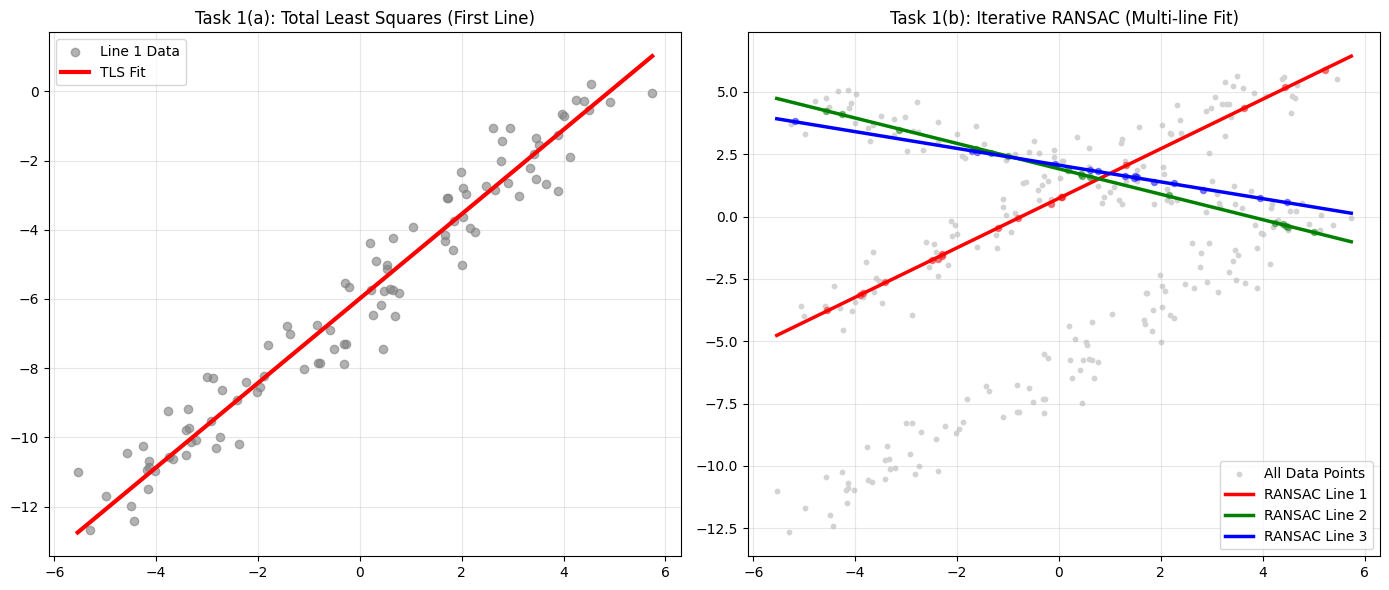

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def fit_tls(x, y):
    """
    Fits a line ax + by + c = 0 using Total Least Squares.
    Minimizes orthogonal distances to the line.
    """
    x_mean, y_mean = np.mean(x), np.mean(y)
    # Center the data
    u = np.vstack([x - x_mean, y - y_mean]).T
    # Singular Value Decomposition
    _, _, vh = np.linalg.svd(u)
    # The normal vector (a, b) is the last row of vh (smallest singular value)
    a, b = vh[-1]
    c = -(a * x_mean + b * y_mean)
    return a, b, c

def run_ransac(x, y, iterations=500, threshold=0.05):
    """
    Finds the best line in a noisy dataset using the RANSAC algorithm.
    """
    best_inliers = []
    best_params = (0, 0, 0)
    n_points = len(x)
    
    for _ in range(iterations):
        # Sample 2 random points to define a model
        idx = np.random.choice(n_points, 2, replace=False)
        p1, p2 = np.array([x[idx], y[idx]]).T
        
        # Line coefficients: (y2-y1)x - (x2-x1)y + x2y1 - y2x1 = 0
        a = p2[1] - p1[1]
        b = p1[0] - p2[0]
        c = p2[0] * p1[1] - p2[1] * p1[0]
        
        norm = np.sqrt(a**2 + b**2)
        if norm == 0: continue
        a, b, c = a/norm, b/norm, c/norm
        
        # Distance from all points to this line
        distances = np.abs(a*x + b*y + c)
        inliers = np.where(distances < threshold)[0]
        
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_params = (a, b, c)
            
    return best_params, best_inliers

def get_line_endpoints(a, b, c, x_data):
    """
    Converts implicit line equation ax + by + c = 0 to (x, y) 
    endpoints for plotting across the data range.
    """
    x_range = np.array([np.min(x_data), np.max(x_data)])
    if b != 0:
        y_range = -(a * x_range + c) / b
    else:
        # Vertical line case
        y_range = x_range 
    return x_range, y_range

# ==========================================
# 1. DATA LOADING & PREPARATION
# ==========================================
try:
    data = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)
except Exception as e:
    print(f"Error loading lines.csv: {e}")
    exit()

# Subset for Task 1(a): First line data (columns x1 and y1)
x1, y1 = data[:, 0], data[:, 3]

# Subset for Task 1(b): Flattened data from all three lines
X_all = data[:, :3].flatten()
Y_all = data[:, 3:].flatten()

# Setup the Plotting Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================
# 2. TASK 1(a): TOTAL LEAST SQUARES
# ==========================================
a_t, b_t, c_t = fit_tls(x1, y1)
print("--- Task 1(a): Total Least Squares ---")
print(f"Parameters: {a_t:.4f}x + {b_t:.4f}y + {c_t:.4f} = 0\n")

# Plotting 1(a)
ax1.scatter(x1, y1, color='gray', alpha=0.6, label='Line 1 Data')
lx, ly = get_line_endpoints(a_t, b_t, c_t, x1)
ax1.plot(lx, ly, color='red', linewidth=3, label='TLS Fit')
ax1.set_title("Task 1(a): Total Least Squares (First Line)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ==========================================
# 3. TASK 1(b): ITERATIVE RANSAC
# ==========================================
print("--- Task 1(b): Iterative RANSAC (3 Lines) ---")
remaining_x, remaining_y = X_all.copy(), Y_all.copy()
colors = ['red', 'green', 'blue']

# Plot initial points for context
ax2.scatter(X_all, Y_all, color='lightgray', s=10, label='All Data Points')

for i in range(3):
    # Find the best line in the current remaining pool of points
    params, inlier_idx = run_ransac(remaining_x, remaining_y)
    a, b, c = params
    
    print(f"Line {i+1} found: {a:.4f}x + {b:.4f}y + {c:.4f} = 0")
    
    # Generate points for plotting the line
    lx, ly = get_line_endpoints(a, b, c, X_all)
    ax2.plot(lx, ly, color=colors[i], linewidth=2.5, label=f'RANSAC Line {i+1}')
    
    # Highlight the specific inliers used for this line
    ax2.scatter(remaining_x[inlier_idx], remaining_y[inlier_idx], 
                color=colors[i], s=20, alpha=0.4)
    
    # IMPORTANT: Remove the consensus points so the next RANSAC run finds a different line
    remaining_x = np.delete(remaining_x, inlier_idx)
    remaining_y = np.delete(remaining_y, inlier_idx)

ax2.set_title("Task 1(b): Iterative RANSAC (Multi-line Fit)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

--- Task 1(a): Total Least Squares ---
Parameters: 0.7736x + -0.6337y + -3.7942 = 0

--- Task 1(b): Iterative RANSAC (3 Lines) ---
Line 1 found: 0.4805x + 0.8770y + -1.9619 = 0
Line 2 found: 0.7152x + -0.6989y + 0.7251 = 0
Line 3 found: 0.7736x + -0.6337y + -3.9227 = 0


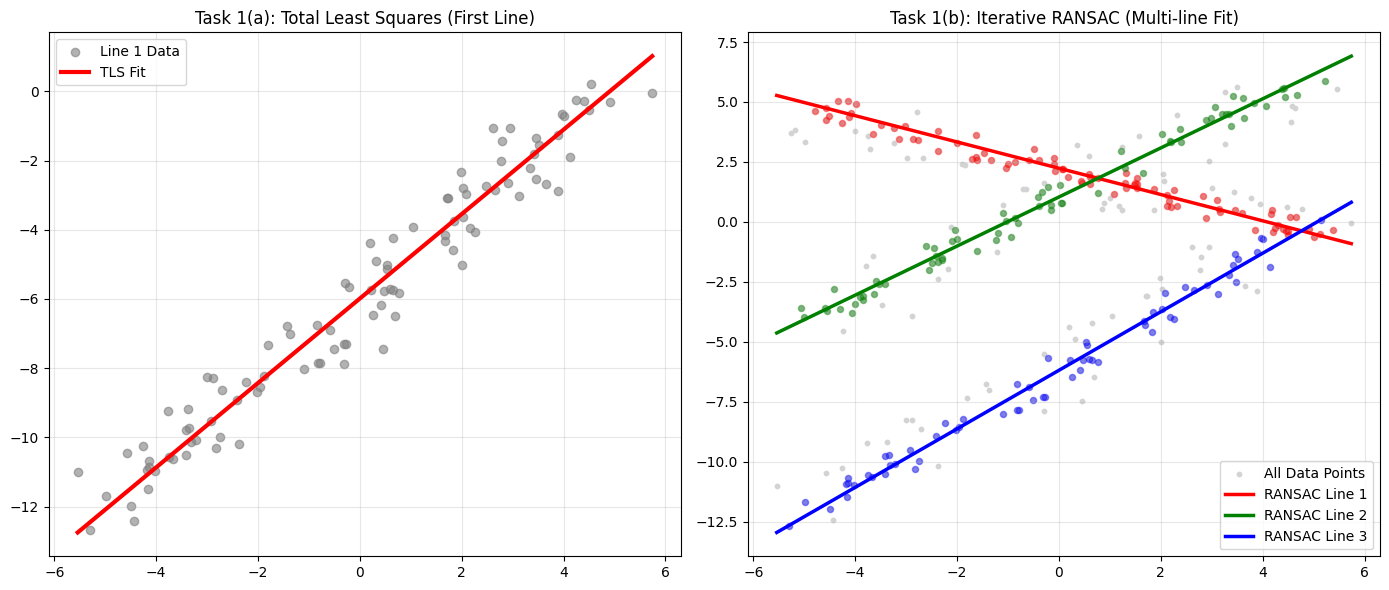

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def fit_tls(x, y):
    """
    Fits a line ax + by + c = 0 using Total Least Squares.
    Minimizes orthogonal distances to the line.
    """
    x_mean, y_mean = np.mean(x), np.mean(y)
    # Center the data
    u = np.vstack([x - x_mean, y - y_mean]).T
    # Singular Value Decomposition
    _, _, vh = np.linalg.svd(u)
    # The normal vector (a, b) is the last row of vh (smallest singular value)
    a, b = vh[-1]
    c = -(a * x_mean + b * y_mean)
    return a, b, c

def run_ransac(x, y, iterations=1000, threshold=0.5):
    """
    Finds the best line in a noisy dataset using the RANSAC algorithm.
    """
    best_inliers = []
    best_params = (0, 0, 0)
    n_points = len(x)
    
    for _ in range(iterations):
        # Sample 2 random points to define a model
        idx = np.random.choice(n_points, 2, replace=False)
        p1, p2 = np.array([x[idx], y[idx]]).T
        
        # Line coefficients: (y2-y1)x - (x2-x1)y + x2y1 - y2x1 = 0
        a = p2[1] - p1[1]
        b = p1[0] - p2[0]
        c = p2[0] * p1[1] - p2[1] * p1[0]
        
        norm = np.sqrt(a**2 + b**2)
        if norm == 0: continue
        a, b, c = a/norm, b/norm, c/norm
        
        # Distance from all points to this line
        distances = np.abs(a*x + b*y + c)
        inliers = np.where(distances < threshold)[0]
        
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_params = (a, b, c)
            
    return best_params, best_inliers

def get_line_endpoints(a, b, c, x_data):
    """
    Converts implicit line equation ax + by + c = 0 to (x, y) 
    endpoints for plotting across the data range.
    """
    x_range = np.array([np.min(x_data), np.max(x_data)])
    if b != 0:
        y_range = -(a * x_range + c) / b
    else:
        # Vertical line case
        y_range = x_range 
    return x_range, y_range

# ==========================================
# 1. DATA LOADING & PREPARATION
# ==========================================
try:
    data = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)
except Exception as e:
    print(f"Error loading lines.csv: {e}")
    exit()

# Subset for Task 1(a): First line data (columns x1 and y1)
x1, y1 = data[:, 0], data[:, 3]

# Subset for Task 1(b): Flattened data from all three lines
X_all = data[:, :3].flatten()
Y_all = data[:, 3:].flatten()

# Setup the Plotting Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================
# 2. TASK 1(a): TOTAL LEAST SQUARES
# ==========================================
a_t, b_t, c_t = fit_tls(x1, y1)
print("--- Task 1(a): Total Least Squares ---")
print(f"Parameters: {a_t:.4f}x + {b_t:.4f}y + {c_t:.4f} = 0\n")

# Plotting 1(a)
ax1.scatter(x1, y1, color='gray', alpha=0.6, label='Line 1 Data')
lx, ly = get_line_endpoints(a_t, b_t, c_t, x1)
ax1.plot(lx, ly, color='red', linewidth=3, label='TLS Fit')
ax1.set_title("Task 1(a): Total Least Squares (First Line)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ==========================================
# 3. TASK 1(b): ITERATIVE RANSAC
# ==========================================
print("--- Task 1(b): Iterative RANSAC (3 Lines) ---")
remaining_x, remaining_y = X_all.copy(), Y_all.copy()
colors = ['red', 'green', 'blue']

# Plot initial points for context
ax2.scatter(X_all, Y_all, color='lightgray', s=10, label='All Data Points')

for i in range(3):
    # Find the best line in the current remaining pool of points
    params, inlier_idx = run_ransac(remaining_x, remaining_y)
    a, b, c = params
    
    print(f"Line {i+1} found: {a:.4f}x + {b:.4f}y + {c:.4f} = 0")
    
    # Generate points for plotting the line
    lx, ly = get_line_endpoints(a, b, c, X_all)
    ax2.plot(lx, ly, color=colors[i], linewidth=2.5, label=f'RANSAC Line {i+1}')
    
    # Highlight the specific inliers used for this line
    ax2.scatter(remaining_x[inlier_idx], remaining_y[inlier_idx], 
                color=colors[i], s=20, alpha=0.4)
    
    # IMPORTANT: Remove the consensus points so the next RANSAC run finds a different line
    remaining_x = np.delete(remaining_x, inlier_idx)
    remaining_y = np.delete(remaining_y, inlier_idx)

ax2.set_title("Task 1(b): Iterative RANSAC (Multi-line Fit)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()